CONVERGENCE STUDY- looking at charge stepping, time stepping, and spatial precision

In [2]:
# imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

import re
# env confirmation
print("Python executable:", sys.executable)

# plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Setup complete.")


Python executable: /Users/k92/clustering_env/bin/python
Setup complete.


In [3]:
#verify imports real quick
import numpy
import pandas
import h5py
import matplotlib
import seaborn
from pathlib import Path

print("All imports successful.")


All imports successful.


In [4]:
# set where hdf5 files live in order to loop through for plotting
# assumes they live within this repo as ./metrics/
# filename convention:
# ./metrics/metrics_<particle>_<energy><unit>_<optional_suffix>.h5

metrics_dir = Path("./metrics")

FNAME_RE = re.compile(
    r"^metrics_(?P<particle>.+)_(?P<energy>\d+)(?P<unit>keV|MeV|GeV)(?:_(?P<suffix>.*))?\.h5$",
    re.IGNORECASE
)

def parse_run_name(fname: str):
    """
    Parses filenames like:
      metrics_alpha_500keV_1000cs.h5

    Returns:
      particle, energy_keV, energy_text, suffix, run_id
    """
    m = FNAME_RE.match(fname)
    if not m:
        return None

    particle = m.group("particle")
    energy_num = int(m.group("energy"))
    unit_original = m.group("unit")
    unit = unit_original.lower()
    suffix = m.group("suffix")

    energy_keV = float(energy_num)
    if unit == "mev":
        energy_keV *= 1e3
    elif unit == "gev":
        energy_keV *= 1e6

    energy_text = f"{energy_num}{unit_original}"

    if suffix:
        run_id = f"{particle}_{energy_text}_{suffix}"
    else:
        run_id = f"{particle}_{energy_text}"

    return {
        "particle": particle,
        "energy_keV": energy_keV,
        "energy_text": energy_text,
        "suffix": suffix,
        "run_id": run_id,
    }

print("Metrics folder:", metrics_dir.resolve())
print("Expected naming: metrics_<particle>_<energy><unit>_<optional_suffix>.h5")

Metrics folder: /Users/k92/Allpix2ClusteringExample/metrics
Expected naming: metrics_<particle>_<energy><unit>_<optional_suffix>.h5


In [5]:
UNIT_TO_KEV = {"kev": 1, "mev": 1_000, "gev": 1_000_000}

def parse_energy_to_keV(text: str):
    """
    Parse strings like: '10keV', '1MeV', '2GeV' -> energy_keV (int)
    Returns (energy_keV, unit) or (None, None) if not parseable.
    """
    m = re.match(r"^\s*(\d+)\s*(keV|MeV|GeV)\s*$", text, re.IGNORECASE)
    if not m:
        return None, None
    val = int(m.group(1))
    unit = m.group(2).lower()
    return val * UNIT_TO_KEV[unit], unit

def parse_run_from_folder(folder_name: str):
    """
    returns dict with particle, energy_keV, energy_text, suffix, run_id
    Accepts:
      gamma_10keV
      gamma_10keV_tcad
    """
    m = re.match(
        r"^(?P<particle>.+)_(?P<energy>\d+(?:keV|MeV|GeV))(?:_(?P<suffix>.*))?$",
        folder_name,
        re.IGNORECASE
    )
    if not m:
        return None

    particle = m.group("particle")
    energy_text = m.group("energy")
    suffix = m.group("suffix")  # will be None if not present

    energy_keV, unit = parse_energy_to_keV(energy_text)
    if energy_keV is None:
        return None

    if suffix:
        run_id = f"{particle}_{energy_text}_{suffix}"
    else:
        run_id = f"{particle}_{energy_text}"

    return {
        "particle": particle,
        "energy_keV": energy_keV,
        "energy_text": energy_text,
        "suffix": suffix,
        "run_id": run_id,
    }

def parse_run_from_metrics_filename(fname: str):
    """
    returns dict with particle, energy_keV, energy_text, suffix, run_id
    Accepts:
      metrics_gamma_10keV.h5
      metrics_gamma_10keV_tcad.h5
    """
    m = re.match(
        r"^metrics_(?P<particle>.+)_(?P<energy>\d+(?:keV|MeV|GeV))(?:_(?P<suffix>.*))?\.h5$",
        fname,
        re.IGNORECASE
    )
    if not m:
        return None

    particle = m.group("particle")
    energy_text = m.group("energy")
    suffix = m.group("suffix")  # will be None if not present

    energy_keV, unit = parse_energy_to_keV(energy_text)
    if energy_keV is None:
        return None
    
    if suffix:
        run_id = f"{particle}_{energy_text}_{suffix}"
    else:
        run_id = f"{particle}_{energy_text}"

    return {
        "particle": particle,
        "energy_keV": energy_keV,
        "energy_text": energy_text,
        "suffix": suffix,
        "run_id": run_id,
    }

print("run parsing helpers ready.")


run parsing helpers ready.


In [6]:
# load all hdf5

metrics_dir = Path("./metrics")
files = sorted(metrics_dir.glob("metrics_*.h5"))

print("Found files:")
for f in files:
    print("  ", f.name)

all_runs = []

for file in files:
    info = parse_run_from_metrics_filename(file.name)

    if info is None:
        print(f"Skipping {file.name} (name not recognized)")
        continue

    with h5py.File(file, "r") as f:
        dset = f["clusters"]
        data_array = dset[:]
        columns = list(dset.attrs["columns"])

    df = pd.DataFrame(data_array, columns=columns)

    # add labels
    df["particle"] = info["particle"]
    df["energy_keV"] = info["energy_keV"]
    df["energy_text"] = info["energy_text"]
    df["suffix"] = info["suffix"]
    df["run"] = info["run_id"]
    df["source_file"] = file.name

    all_runs.append(df)

if not all_runs:
    raise ValueError("No valid metric files were loaded.")

data = pd.concat(all_runs, ignore_index=True)

print("\nLoaded dataframe shape:", data.shape)
print("Number of runs loaded:", data["run"].nunique())

print("\nAlpha 500keV runs loaded:")
for r in sorted(data["run"].unique()):
    if "alpha" in str(r).lower() and "500kev" in str(r).lower():
        print(" ", repr(r))


Found files:
   metrics_alpha_100MeV_1cm.h5
   metrics_alpha_100keV_1cm.h5
   metrics_alpha_10MeV_1cm.h5
   metrics_alpha_10keV_1cm.h5
   metrics_alpha_1MeV_1cm.h5
   metrics_alpha_200MeV_1cm.h5
   metrics_alpha_500MeV_1cm.h5
   metrics_alpha_500keV_1000cs.h5
   metrics_alpha_500keV_100cs.h5
   metrics_alpha_500keV_175cs.h5
   metrics_alpha_500keV_250cs.h5
   metrics_alpha_500keV_325cs.h5
   metrics_alpha_500keV_400cs.h5
   metrics_alpha_500keV_475cs.h5
   metrics_alpha_500keV_550cs.h5
   metrics_alpha_500keV_625cs.h5
   metrics_alpha_500keV_700cs.h5
   metrics_alpha_500keV_775cs.h5
   metrics_alpha_500keV_850cs.h5
   metrics_alpha_500keV_925cs.h5
   metrics_alpha_50MeV_1cm.h5
   metrics_electron_100MeV_1cm.h5
   metrics_electron_100keV_1cm.h5
   metrics_electron_10MeV_1cm.h5
   metrics_electron_1MeV_1cm.h5
   metrics_electron_200MeV_1cm.h5
   metrics_electron_200keV_1cm.h5
   metrics_electron_500MeV_1cm.h5
   metrics_electron_500keV_1cm.h5
   metrics_electron_50keV_1cm.h5
   metrics_g

In [7]:
#charge to energy
# Q_cluster is total electrons per cluster (sum of |charge| per pixel)
# Silicon: ~3.6 eV per electron-hole pair
EV_PER_EH = 3.64

# Convert electrons -> keV and MeV
data["E_cluster_keV"] = data["Q_cluster"] * EV_PER_EH / 1000.0
# per-cluster "energy density" 
data["energy_density"] = data["E_cluster_keV"] / data["n_hits"].replace(0, np.nan)
#get rid of all Q_cluster
#data.drop(columns=["Q_cluster"], inplace=True)
# permanent master copy (IMPORTANT)
data_all = data.copy()

print("data_all shape:", data_all.shape)

data_all shape: (480203, 26)


In [8]:
# selection- can opt to only analyze spcific runs, can choose "all", "particles", "pairs", or "runs"
# creates:
#   data_all = full dataset (keep)
#   data     = filtered dataset (use for all later cells)

# use the already-created full dataset
data = data_all.copy()

# ------------------- CHOOSE ONE MODE -------------------


MODE = "runs"          

# option A: choose particles type
SELECT_PARTICLES = ["gamma"]     # e.g. ["alpha"] 

# option B: choose specific (particle, energy_keV) pairs
# remember: it has all been converted to keV so 1 MeV = 1000 keV, 10 MeV = 10000 keV, 1 GeV = 1_000_000 keV !!!
SELECT_PAIRS = [
    ("gamma", 10),
    ("alpha", 1000),
    ("proton", 10_000),
    ("electron", 100),
]

# option C: choose specific runs by filename 
# option C: choose specific runs by filename
SELECT_RUNS = [

    # alpha
    "alpha_100MeV_1cm",
    "alpha_100keV_1cm",
    "alpha_10MeV_1cm",
    "alpha_10keV_1cm",
    "alpha_1MeV_1cm",
    "alpha_200MeV_1cm",
    "alpha_500MeV_1cm",
    "alpha_50MeV_1cm",

    # electron
    "electron_100MeV_1cm",
    "electron_100keV_1cm",
    "electron_10MeV_1cm",
    "electron_1MeV_1cm",
    "electron_200MeV_1cm",
    "electron_200keV_1cm",
    "electron_500MeV_1cm",
    "electron_500keV_1cm",
    "electron_50keV_1cm",

    # gamma
    "gamma_100keV_1cm",
    "gamma_10MeV_1cm",
    "gamma_10keV_1cm",
    "gamma_1MeV_1cm",
    "gamma_500keV_1cm",

    # muon+
    "muon+_100keV_1cm",
    "muon+_10keV_1cm",
    "muon+_1MeV_1cm",
    "muon+_500keV_1cm",

    # muon-
    "muon-_100keV_1cm",
    "muon-_10keV_1cm",
    "muon-_1MeV_1cm",
    "muon-_500keV_1cm",

    # proton
    "proton_100MeV_1cm",
    "proton_100keV_1cm",
    "proton_10MeV_1cm",
    "proton_10keV_1cm",
    "proton_1MeV_1cm",
    "proton_200MeV_1cm",
    "proton_500MeV_1cm",
    "proton_50MeV_1cm",
]

# filter applied here
if MODE == "all":
    data = data_all.copy()

elif MODE == "particles":
    data = data_all[data_all["particle"].isin(SELECT_PARTICLES)].copy()

elif MODE == "pairs":
    mask = False
    for p, e in SELECT_PAIRS:
        mask = mask | ((data_all["particle"] == p) & (data_all["energy_keV"] == e))
    data = data_all[mask].copy()

elif MODE == "runs":
    data = data_all[data_all["run"].isin(SELECT_RUNS)].copy()

else:
    raise ValueError(f"Unknown MODE: {MODE}")

# summary
print("Selection MODE:", MODE)
print("Selected shape:", data.shape)
print("Selected particles:", sorted(data["particle"].unique()))
print("Selected runs:", sorted(data["run"].unique())[:15]) #can limit to only first x amount of runs


Selection MODE: runs
Selected shape: (342916, 26)
Selected particles: ['alpha', 'electron', 'gamma', 'muon+', 'muon-', 'proton']
Selected runs: ['alpha_100MeV_1cm', 'alpha_100keV_1cm', 'alpha_10MeV_1cm', 'alpha_10keV_1cm', 'alpha_1MeV_1cm', 'alpha_200MeV_1cm', 'alpha_500MeV_1cm', 'alpha_50MeV_1cm', 'electron_100MeV_1cm', 'electron_100keV_1cm', 'electron_10MeV_1cm', 'electron_1MeV_1cm', 'electron_200MeV_1cm', 'electron_200keV_1cm', 'electron_500MeV_1cm']


In [10]:
# sanity check to make sure it is all loaded properly
core_metrics = [
    "E_cluster_keV",
    "n_hits",
    "bbox_area",
    "fill_factor",
    "mean_r",
    "rms_r",
    "r90",
    "axis_asym_qw",
    "axis_skew_qw",
    "neighbor_frac",
]
# make sure these columns exist
missing = [c for c in core_metrics if c not in data.columns]
if missing:
    print("WARNING: missing expected columns:", missing)

# summary per run
summary = (
    data.groupby(["particle", "energy_keV", "run"], as_index=False)
        .agg(
            n_clusters=("cluster_id", "count"),

            # size
            n_hits_median=("n_hits", "median"),
            n_hits_mean=("n_hits", "mean"),
            
            # bbox / geometric size 
            bbox_area_median=("bbox_area", "median"),
            bbox_area_mean=("bbox_area", "mean"),

            # energy proxy
            E_median=("E_cluster_keV", "median"),
            E_mean=("E_cluster_keV", "mean"),

            # totals needed for energy density
            E_total=("E_cluster_keV", "sum"),
            n_hits_total=("n_hits", "sum"),

            # occupancy
            fill_median=("fill_factor", "median"),
            fill_mean=("fill_factor", "mean"),

            # spread
            r90_median=("r90", "median"),
            rms_median=("rms_r", "median"),

            # neighbor/connectivity
            neighbor_median=("neighbor_frac", "median"),

            asym_qw_median=("axis_asym_qw", "median"),
            asym_qw_mean=("axis_asym_qw", "mean"),

            skew_qw_median=("axis_skew_qw", lambda x: np.nanmedian(x)),
            skew_qw_mean=("axis_skew_qw", lambda x: np.nanmean(x)),

            # skewness skip rate from your stored flag (if present)
            skew_skipped_rate=("skew_skipped", "mean")
                if "skew_skipped" in data.columns
                else ("n_hits", "mean"),


            track_len_median=("track_length", "median"),
            track_len_mean=("track_length", "mean"),    
        )
)

# energy density per run (method B)
summary["energy_density_keV_per_hit"] = summary["E_total"] / summary["n_hits_total"]

# sanity checks
bad_fill = (data["fill_factor"] > 1).sum() if "fill_factor" in data.columns else 0
bad_neighbor = ((data["neighbor_frac"] < 0) | (data["neighbor_frac"] > 1)).sum() if "neighbor_frac" in data.columns else 0

print("Sanity checks:")
print("  fill_factor > 1 count:", int(bad_fill))
print("  neighbor_frac outside [0,1] count:", int(bad_neighbor))
print("\nRun-level summary:")
summary.sort_values(["particle", "energy_keV"]).head(40)


Sanity checks:
  fill_factor > 1 count: 0
  neighbor_frac outside [0,1] count: 0

Run-level summary:


,particle,energy_keV,run,n_clusters,n_hits_median,n_hits_mean,bbox_area_median,bbox_area_mean,E_median,E_mean,...,rms_median,neighbor_median,asym_qw_median,asym_qw_mean,skew_qw_median,skew_qw_mean,skew_skipped_rate,track_len_median,track_len_mean,energy_density_keV_per_hit
0,alpha,10,alpha_10keV_1cm,9820,1.0,1.343992,1.0,1.362016,7.36372,7.132738,...,0.000000,0.0,0.000000,0.082255,-5.414072e-03,-0.008257,0.990733,0.000000,0.340071,5.307129
1,alpha,100,alpha_100keV_1cm,9882,5.0,5.243574,6.0,6.331107,96.56738,96.337439,...,0.910570,1.0,0.229019,0.258967,5.339642e-03,0.003885,0.001720,1.981910,1.786714,18.372476
2,alpha,1000,alpha_1MeV_1cm,9869,23.0,22.572500,30.0,30.447056,991.66340,987.928057,...,1.918534,1.0,0.099932,0.113821,8.367035e-04,0.000487,0.000912,4.985085,4.900808,43.766887
3,alpha,10000,alpha_10MeV_1cm,9947,39.0,38.903388,56.0,55.214638,9993.97308,9890.141042,...,2.535326,1.0,0.092597,0.105354,-5.926819e-04,-0.000595,0.006233,6.707545,6.737733,254.223130
4,alpha,50000,alpha_50MeV_1cm,9931,14.0,13.780183,16.0,17.164233,8660.85948,8620.733582,...,1.483665,1.0,0.292683,0.303485,-1.444281e-02,-0.008671,0.002316,3.103781,3.210518,625.589182
5,alpha,100000,alpha_100MeV_1cm,9936,10.0,9.842089,12.0,12.205213,4761.66236,4772.044411,...,1.250445,1.0,0.365706,0.370854,-1.701735e-02,-0.009470,0.002013,3.002919,2.813014,484.860910
6,alpha,200000,alpha_200MeV_1cm,9938,7.0,7.226202,9.0,8.797243,2730.39312,2743.529390,...,1.043736,1.0,0.428646,0.426800,-2.207775e-03,0.003982,0.006541,2.032927,1.997899,379.664064
7,alpha,500000,alpha_500MeV_1cm,9987,6.0,5.858116,6.0,7.434665,1344.49224,1381.053883,...,0.969540,1.0,0.495874,0.479236,-2.022726e-03,-0.003928,0.008010,1.259947,1.749821,235.750536
8,electron,50,electron_50keV_1cm,7662,2.0,1.668363,2.0,1.722396,40.87538,34.447181,...,0.502462,1.0,0.073905,0.263883,1.966477e-02,0.032394,0.907987,1.000000,0.559617,20.647289
9,electron,100,electron_100keV_1cm,9772,2.0,2.250000,2.0,2.432665,95.19328,83.115571,...,0.611858,1.0,0.373174,0.396945,2.175563e-04,0.016580,0.685121,1.000000,0.871619,36.940254


Reference run: 100 charge_per_step


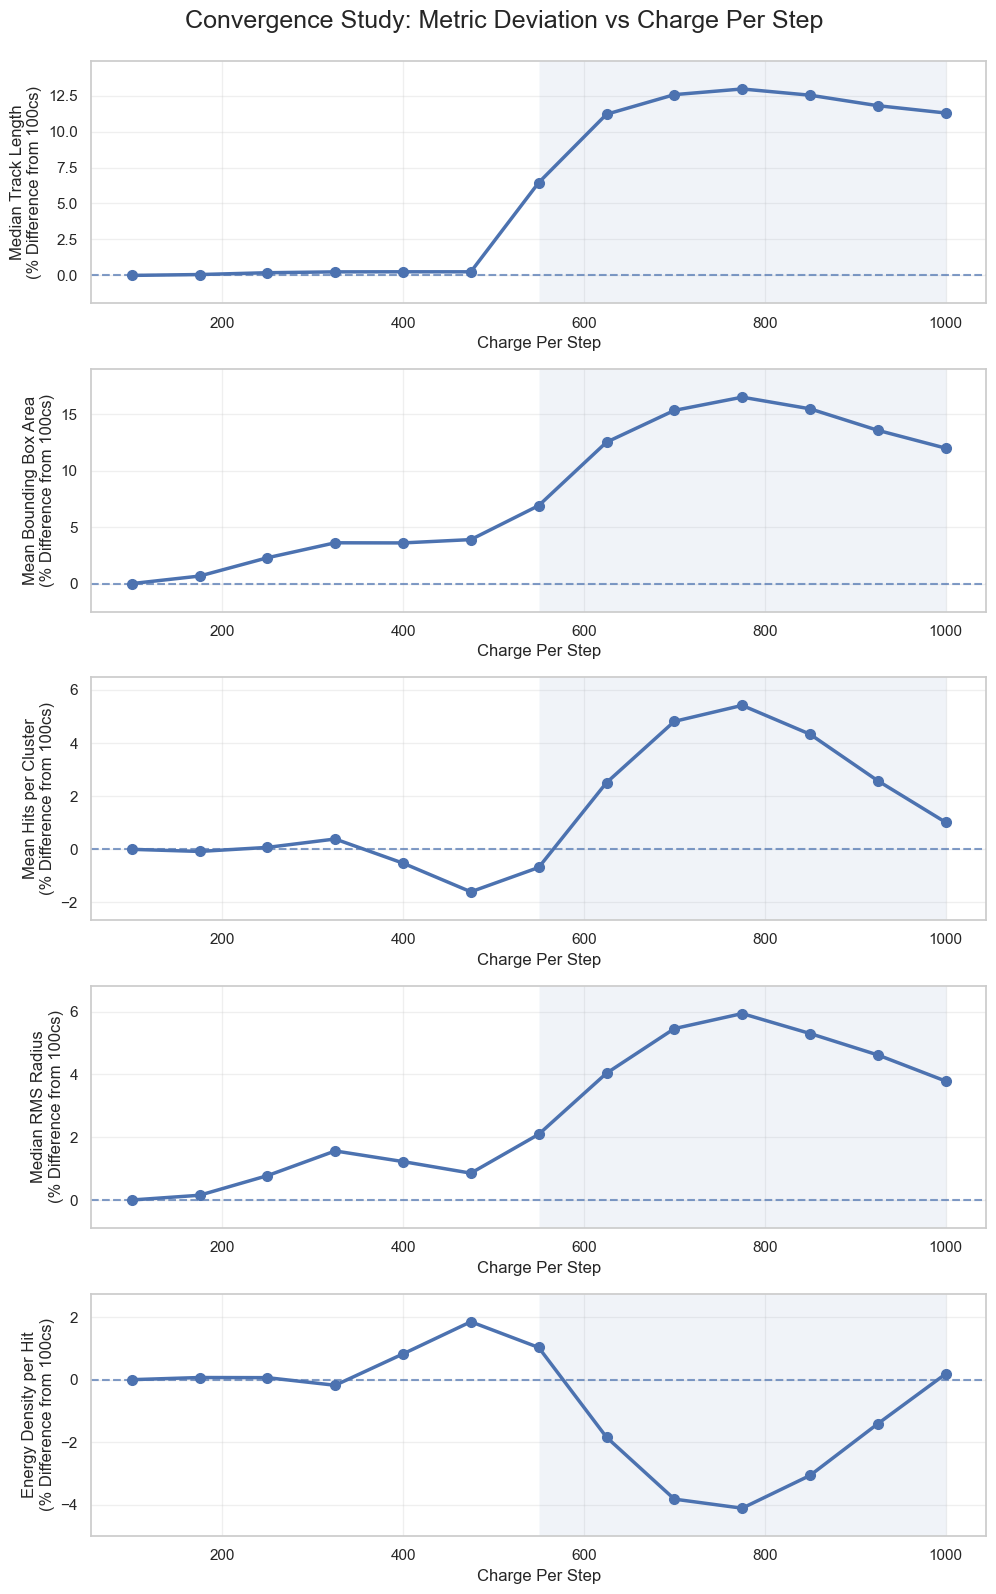

In [ ]:
#USE THIS WHEN LOOKING AT CONVERGENCE OF CHARGE STEPPING
#use runs ending in cs (for charge step)
# convergence study for charge stepping
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------
# Prepare dataframe
# ----------------------------------------

conv = summary.copy()

# Extract charge_per_step from run names
conv["charge_per_step"] = (
    conv["run"]
    .str.extract(r"_(\d+)cs")[0]
    .astype(int)
)

conv = conv.sort_values("charge_per_step").reset_index(drop=True)

# ----------------------------------------
# Metrics to study
# ----------------------------------------

metrics_info = {
    "track_len_median": {
        "label": "Median Track Length\n(% Difference from 100cs)"
    },

    "bbox_area_mean": {
        "label": "Mean Bounding Box Area\n(% Difference from 100cs)"
    },

    "n_hits_mean": {
        "label": "Mean Hits per Cluster\n(% Difference from 100cs)"
    },

    "rms_median": {
        "label": "Median RMS Radius\n(% Difference from 100cs)"
    },

    "energy_density_keV_per_hit": {
        "label": "Energy Density per Hit\n(% Difference from 100cs)"
    },
}

# ----------------------------------------
# Reference run (lowest CPS)
# ----------------------------------------

ref_step = conv["charge_per_step"].min()
ref_row = conv.loc[
    conv["charge_per_step"] == ref_step
].iloc[0]

print(f"Reference run: {ref_step} charge_per_step")

# ----------------------------------------
# Plot styling
# ----------------------------------------

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

fig, axes = plt.subplots(
    len(metrics_info),
    1,
    figsize=(10, 16),
    sharex=False
)

# If only one metric
if len(metrics_info) == 1:
    axes = [axes]

# ----------------------------------------
# Create plots
# ----------------------------------------

for ax, (metric, info) in zip(axes, metrics_info.items()):

    ref_value = ref_row[metric]

    percent_diff = (
        (conv[metric] - ref_value)
        / ref_value
    ) * 100

    ax.plot(
        conv["charge_per_step"],
        percent_diff,
        marker="o",
        linewidth=2.5,
        markersize=7,
    )

    # Reference line
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7
    )

    # Approximate transition region
    ax.axvspan(
        550,
        1000,
        alpha=0.08
    )

    # Labels
    ax.set_ylabel(info["label"])
    ax.set_xlabel("Charge Per Step")

    # Cleaner look
    ax.grid(alpha=0.3)

    # Slight padding
    ymin = percent_diff.min()
    ymax = percent_diff.max()

    pad = 0.15 * (ymax - ymin + 1e-6)

    ax.set_ylim(ymin - pad, ymax + pad)


# Overall title 
fig.suptitle(
    "Convergence Study: Metric Deviation vs Charge Per Step",
    fontsize=18,
    y=0.995
)

plt.tight_layout()
plt.show()

In [ ]:
#USE THIS WHEN LOOKING AT CONVERGENCE OF SPATIAL PRECISION
# #use runs ending in sp (for spatial precision) 

In [ ]:
#USE THIS WHEN LOOKING AT CONVERGENCE OF TIME STEPPING
#use runs ending in ts (for time step)

In [ ]:
# energy histograms and pixel hit maps (RUN-LEVEL)

metrics_dir = Path("./metrics") #again just in case

CHARGE_COL = "E_cluster_keV"   # cluster-level charge proxy

BINS = 120
HIST_DENSITY = True
HIST_LOGY = False
MAX_RUNS_TO_PLOT = None

# selected runs from earlier
selected_runs = sorted(data["run"].unique())
if MAX_RUNS_TO_PLOT is not None:
    selected_runs = selected_runs[:MAX_RUNS_TO_PLOT]

print(f"Selected runs ({len(selected_runs)}):")
for r in selected_runs[:20]:
    print(" ", r)

# load and plot charge maps
run_hit_maps = {}

for run in selected_runs:
    h5_path = metrics_dir / f"metrics_{run}.h5"

    if not h5_path.exists():
        print(f"WARNING: Missing HDF5 for run '{run}'")
        print("  looked for:", h5_path)
        continue

    with h5py.File(h5_path, "r") as f:
        if "run_hit_map" not in f:
            print(f"WARNING: '{run}' has no 'run_hit_map'")
            continue
        run_hit_maps[run] = f["run_hit_map"][:]

# plot one map per run
for run, hit_map in run_hit_maps.items():
    plt.figure(figsize=(6, 5))
    plt.imshow(hit_map, origin="lower", aspect="equal")
    plt.colorbar(label="Summed |Charge| per pixel")
    plt.title(f"Run-level charge map: {run}")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.tight_layout()
    plt.show()

# charge histograms
if CHARGE_COL not in data.columns:
    print(f"WARNING: '{CHARGE_COL}' not found in data.columns")
else:
    plt.figure(figsize=(8, 5))

    vals_all = data[CHARGE_COL].to_numpy()
    vals_all = vals_all[np.isfinite(vals_all)]
    bin_edges = np.histogram_bin_edges(vals_all, bins=BINS)

    for run in selected_runs:
        run_vals = data.loc[data["run"] == run, CHARGE_COL].to_numpy()
        run_vals = run_vals[np.isfinite(run_vals)]
        if len(run_vals) == 0:
            continue

        plt.hist(run_vals,
                 bins=bin_edges,
                 histtype="step",
                 density=HIST_DENSITY,
                 label=run)

    plt.xlabel("Cluster Energy (keV)")
    plt.ylabel("Density" if HIST_DENSITY else "Count")
    plt.title("Cluster Energy Distributions Across Selected Runs")

    if HIST_LOGY:
        plt.yscale("log")

    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [12]:
#Energy Similarity
from scipy.stats import wasserstein_distance

run_names = sorted(data["run"].unique())

combined_similarity = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
combined_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

energy_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
density_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

# weights
w_energy = 0.5
w_density = 0.5

for run_a in run_names:
    ea = data.loc[data["run"] == run_a, "E_cluster_keV"].to_numpy()
    ea = ea[np.isfinite(ea)]

    da = data.loc[data["run"] == run_a, "energy_density"].to_numpy()
    da = da[np.isfinite(da)]

    for run_b in run_names:
        eb = data.loc[data["run"] == run_b, "E_cluster_keV"].to_numpy()
        eb = eb[np.isfinite(eb)]

        db = data.loc[data["run"] == run_b, "energy_density"].to_numpy()
        db = db[np.isfinite(db)]

        if len(ea) == 0 or len(eb) == 0 or len(da) == 0 or len(db) == 0:
            dE = np.nan
            dD = np.nan
            d_total = np.nan
            sim = np.nan
        else:
            # pairwise scaling for energy
            scale_E = np.std(np.concatenate([ea, eb]))
            if scale_E == 0 or not np.isfinite(scale_E):
                scale_E = 1.0

            # pairwise scaling for energy density
            scale_D = np.std(np.concatenate([da, db]))
            if scale_D == 0 or not np.isfinite(scale_D):
                scale_D = 1.0

            dE = wasserstein_distance(ea, eb) / scale_E
            dD = wasserstein_distance(da, db) / scale_D

            d_total = w_energy * dE + w_density * dD
            sim = 1.0 / (1.0 + d_total)

        energy_distance.loc[run_a, run_b] = dE
        density_distance.loc[run_a, run_b] = dD
        combined_distance.loc[run_a, run_b] = d_total
        combined_similarity.loc[run_a, run_b] = sim

print("Combined energy + energy density similarity matrix:")
display(combined_similarity)

Combined energy + energy density similarity matrix:


,alpha_100MeV_1cm,alpha_100keV_1cm,alpha_10MeV_1cm,alpha_10keV_1cm,alpha_1MeV_1cm,alpha_200MeV_1cm,alpha_500MeV_1cm,alpha_50MeV_1cm,electron_100MeV_1cm,electron_100keV_1cm,...,muon-_1MeV_1cm,muon-_500keV_1cm,proton_100MeV_1cm,proton_100keV_1cm,proton_10MeV_1cm,proton_10keV_1cm,proton_1MeV_1cm,proton_200MeV_1cm,proton_500MeV_1cm,proton_50MeV_1cm
alpha_100MeV_1cm,1.000000,0.338728,0.346754,0.338517,0.340689,0.413452,0.359575,0.379331,0.339774,0.339224,...,0.344141,0.340557,0.342225,0.338736,0.395026,0.338509,0.340844,0.342232,0.340672,0.343168
alpha_100keV_1cm,0.338728,1.000000,0.335815,0.342252,0.337446,0.345638,0.379391,0.336148,0.477914,0.516097,...,0.398456,0.444305,0.401897,0.937112,0.337863,0.341391,0.335777,0.501042,0.545153,0.350863
alpha_10MeV_1cm,0.346754,0.335815,1.000000,0.335711,0.336193,0.362819,0.425447,0.392688,0.339615,0.337508,...,0.343208,0.337028,0.347916,0.335822,0.359131,0.335704,0.336463,0.343603,0.339658,0.355814
alpha_10keV_1cm,0.338517,0.342252,0.335711,1.000000,0.334762,0.344939,0.375251,0.336080,0.378235,0.377841,...,0.390261,0.418225,0.384203,0.342113,0.337577,0.807044,0.334601,0.466100,0.486321,0.347315
alpha_1MeV_1cm,0.340689,0.337446,0.336193,0.334762,1.000000,0.354702,0.451758,0.336528,0.392128,0.408997,...,0.500691,0.496525,0.377807,0.337490,0.340181,0.334686,0.518614,0.423657,0.428909,0.377615
alpha_200MeV_1cm,0.413452,0.345638,0.362819,0.344939,0.354702,1.000000,0.423985,0.353667,0.348021,0.346699,...,0.366049,0.353072,0.355136,0.345655,0.875313,0.344919,0.355151,0.354907,0.350622,0.360170
alpha_500MeV_1cm,0.359575,0.379391,0.425447,0.375251,0.451758,0.423985,1.000000,0.343146,0.388470,0.382697,...,0.473329,0.411022,0.427825,0.379430,0.408746,0.375179,0.454892,0.412370,0.395656,0.485268
alpha_50MeV_1cm,0.379331,0.336148,0.392688,0.336080,0.336528,0.353667,0.343146,1.000000,0.336744,0.336454,...,0.337516,0.336332,0.337699,0.336152,0.349348,0.336076,0.336595,0.337607,0.337010,0.337850
electron_100MeV_1cm,0.339774,0.477914,0.339615,0.378235,0.392128,0.348021,0.388470,0.336744,1.000000,0.563244,...,0.480180,0.532623,0.454355,0.478482,0.339954,0.377799,0.400539,0.667766,0.830745,0.364577
electron_100keV_1cm,0.339224,0.516097,0.337508,0.377841,0.408997,0.346699,0.382697,0.336454,0.563244,1.000000,...,0.431570,0.552582,0.416392,0.518556,0.338809,0.377109,0.376142,0.547545,0.656260,0.355330


In [13]:
#charge shape similarity
from scipy.stats import wasserstein_distance

run_names = sorted(data["run"].unique())

charge_shape_similarity = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
charge_shape_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

asym_qw_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
skew_qw_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
track_length_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

# weights
w_asym = 0.4
w_skew = 0.4
w_track = 0.2

for run_a in run_names:
    aa = data.loc[data["run"] == run_a, "axis_asym_qw"].to_numpy()
    aa = aa[np.isfinite(aa)]

    sa = data.loc[data["run"] == run_a, "axis_skew_qw"].to_numpy()
    sa = sa[np.isfinite(sa)]

    ta = data.loc[data["run"] == run_a, "track_length"].to_numpy()
    ta = ta[np.isfinite(ta)]

    for run_b in run_names:
        ab = data.loc[data["run"] == run_b, "axis_asym_qw"].to_numpy()
        ab = ab[np.isfinite(ab)]

        sb = data.loc[data["run"] == run_b, "axis_skew_qw"].to_numpy()
        sb = sb[np.isfinite(sb)]

        tb = data.loc[data["run"] == run_b, "track_length"].to_numpy()
        tb = tb[np.isfinite(tb)]

        if len(aa) == 0 or len(ab) == 0 or len(sa) == 0 or len(sb) == 0 or len(ta) == 0 or len(tb) == 0:
            dA = np.nan
            dS = np.nan
            dT = np.nan
            d_total = np.nan
            sim = np.nan
        else:
            # pairwise scaling for asymmetry
            scale_A = np.std(np.concatenate([aa, ab]))
            if scale_A == 0 or not np.isfinite(scale_A):
                scale_A = 1.0

            # pairwise scaling for skewness
            scale_S = np.std(np.concatenate([sa, sb]))
            if scale_S == 0 or not np.isfinite(scale_S):
                scale_S = 1.0

            # pairwise scaling for track length
            scale_T = np.std(np.concatenate([ta, tb]))
            if scale_T == 0 or not np.isfinite(scale_T):
                scale_T = 1.0

            dA = wasserstein_distance(aa, ab) / scale_A
            dS = wasserstein_distance(sa, sb) / scale_S
            dT = wasserstein_distance(ta, tb) / scale_T

            d_total = w_asym * dA + w_skew * dS + w_track * dT
            sim = 1.0 / (1.0 + d_total)

        asym_qw_distance.loc[run_a, run_b] = dA
        skew_qw_distance.loc[run_a, run_b] = dS
        track_length_distance.loc[run_a, run_b] = dT
        charge_shape_distance.loc[run_a, run_b] = d_total
        charge_shape_similarity.loc[run_a, run_b] = sim

print("Charge-shape similarity matrix:")
display(charge_shape_similarity)

Charge-shape similarity matrix:


,alpha_100MeV_1cm,alpha_100keV_1cm,alpha_10MeV_1cm,alpha_10keV_1cm,alpha_1MeV_1cm,alpha_200MeV_1cm,alpha_500MeV_1cm,alpha_50MeV_1cm,electron_100MeV_1cm,electron_100keV_1cm,...,muon-_1MeV_1cm,muon-_500keV_1cm,proton_100MeV_1cm,proton_100keV_1cm,proton_10MeV_1cm,proton_10keV_1cm,proton_1MeV_1cm,proton_200MeV_1cm,proton_500MeV_1cm,proton_50MeV_1cm
alpha_100MeV_1cm,1.000000,0.591235,0.427109,0.472854,0.440910,0.699101,0.617687,0.684731,0.549759,0.602721,...,0.675941,0.627167,0.531513,0.596954,0.710901,0.470842,0.468757,0.555617,0.563477,0.533359
alpha_100keV_1cm,0.591235,1.000000,0.456411,0.525463,0.475319,0.589754,0.552868,0.663644,0.483030,0.518514,...,0.748707,0.732066,0.493685,0.955279,0.595609,0.519991,0.500504,0.516565,0.513201,0.487680
alpha_10MeV_1cm,0.427109,0.456411,1.000000,0.394616,0.622257,0.420813,0.419736,0.437158,0.390492,0.415514,...,0.498630,0.521007,0.417237,0.455457,0.422308,0.440833,0.569373,0.417526,0.415169,0.416803
alpha_10keV_1cm,0.472854,0.525463,0.394616,1.000000,0.510847,0.467367,0.477874,0.490613,0.603165,0.530960,...,0.554686,0.585216,0.476906,0.523681,0.467055,0.900894,0.460439,0.508845,0.525181,0.467307
alpha_1MeV_1cm,0.440910,0.475319,0.622257,0.510847,1.000000,0.427610,0.427285,0.457418,0.396739,0.421062,...,0.530526,0.562378,0.420065,0.473315,0.428924,0.546055,0.624118,0.423582,0.420705,0.419427
alpha_200MeV_1cm,0.699101,0.589754,0.420813,0.467367,0.427610,1.000000,0.759310,0.551714,0.624110,0.675798,...,0.608153,0.564737,0.607746,0.592285,0.954710,0.466911,0.442256,0.649068,0.661594,0.606879
alpha_500MeV_1cm,0.617687,0.552868,0.419736,0.477874,0.427285,0.759310,1.000000,0.526255,0.671261,0.717142,...,0.560915,0.530470,0.725486,0.558475,0.733815,0.478305,0.442094,0.765299,0.770648,0.736695
alpha_50MeV_1cm,0.684731,0.663644,0.437158,0.490613,0.457418,0.551714,0.526255,1.000000,0.468354,0.510720,...,0.739419,0.688058,0.477011,0.667738,0.555056,0.485474,0.494261,0.494348,0.493978,0.476812
electron_100MeV_1cm,0.549759,0.483030,0.390492,0.603165,0.396739,0.624110,0.671261,0.468354,1.000000,0.799777,...,0.541187,0.499048,0.652078,0.489125,0.618270,0.606419,0.400880,0.697773,0.759799,0.653664
electron_100keV_1cm,0.602721,0.518514,0.415514,0.530960,0.421062,0.675798,0.717142,0.510720,0.799777,1.000000,...,0.580739,0.536860,0.674969,0.524801,0.667980,0.533846,0.430117,0.725378,0.793212,0.678181


In [14]:
# Geometric similarity
from scipy.stats import wasserstein_distance

geom_metrics = [
    "n_hits",
    "bbox_area",
    "fill_factor",
    "r90",
    "track_length",
    "neighbor_frac",
]

run_names = sorted(data["run"].unique())

geometry_similarity = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
geometry_distance = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

geometry_metric_distances = {}
for m in geom_metrics:
    geometry_metric_distances[m] = pd.DataFrame(index=run_names, columns=run_names, dtype=float)

for run_a in run_names:
    run_a_df = data[data["run"] == run_a]

    for run_b in run_names:
        run_b_df = data[data["run"] == run_b]

        dists = []

        for m in geom_metrics:
            a_vals = run_a_df[m].to_numpy()
            b_vals = run_b_df[m].to_numpy()

            a_vals = a_vals[np.isfinite(a_vals)]
            b_vals = b_vals[np.isfinite(b_vals)]

            if len(a_vals) == 0 or len(b_vals) == 0:
                d_m = np.nan
            else:
                pair_scale = np.std(np.concatenate([a_vals, b_vals]))
                if pair_scale == 0 or not np.isfinite(pair_scale):
                    pair_scale = 1.0

                d_m = wasserstein_distance(a_vals, b_vals) / pair_scale

            geometry_metric_distances[m].loc[run_a, run_b] = d_m

            if np.isfinite(d_m):
                dists.append(d_m)

        if len(dists) == 0:
            dist = np.nan
            sim = np.nan
        else:
            dist = np.mean(dists)
            sim = 1.0 / (1.0 + dist)

        geometry_distance.loc[run_a, run_b] = dist
        geometry_similarity.loc[run_a, run_b] = sim

print("Geometry similarity matrix:")
display(geometry_similarity)

Geometry similarity matrix:


,alpha_100MeV_1cm,alpha_100keV_1cm,alpha_10MeV_1cm,alpha_10keV_1cm,alpha_1MeV_1cm,alpha_200MeV_1cm,alpha_500MeV_1cm,alpha_50MeV_1cm,electron_100MeV_1cm,electron_100keV_1cm,...,muon-_1MeV_1cm,muon-_500keV_1cm,proton_100MeV_1cm,proton_100keV_1cm,proton_10MeV_1cm,proton_10keV_1cm,proton_1MeV_1cm,proton_200MeV_1cm,proton_500MeV_1cm,proton_50MeV_1cm
alpha_100MeV_1cm,1.000000,0.534425,0.405062,0.390566,0.436994,0.633170,0.598125,0.597763,0.423703,0.436094,...,0.748739,0.763487,0.495598,0.532060,0.616059,0.392634,0.502862,0.537572,0.494973,0.494620
alpha_100keV_1cm,0.534425,1.000000,0.396905,0.385601,0.407739,0.632639,0.781947,0.436124,0.450194,0.450115,...,0.627664,0.616809,0.587051,0.962945,0.583985,0.388139,0.418995,0.656645,0.585696,0.583367
alpha_10MeV_1cm,0.405062,0.396905,1.000000,0.350821,0.435515,0.399638,0.407624,0.403804,0.363237,0.373066,...,0.462740,0.441690,0.394143,0.396934,0.395515,0.352138,0.409354,0.405897,0.387194,0.392841
alpha_10keV_1cm,0.390566,0.385601,0.350821,1.000000,0.352104,0.394162,0.439507,0.360108,0.716922,0.512989,...,0.469760,0.456367,0.447208,0.386331,0.374696,0.940154,0.355731,0.558603,0.592064,0.403170
alpha_1MeV_1cm,0.436994,0.407739,0.435515,0.352104,1.000000,0.414969,0.425862,0.434263,0.367424,0.375950,...,0.525172,0.505289,0.399550,0.407767,0.410143,0.353445,0.455341,0.430645,0.403699,0.401419
alpha_200MeV_1cm,0.633170,0.632639,0.399638,0.394162,0.414969,1.000000,0.701656,0.478557,0.440451,0.451347,...,0.668085,0.662911,0.542058,0.626481,0.957871,0.396646,0.442599,0.590937,0.536478,0.532163
alpha_500MeV_1cm,0.598125,0.781947,0.407624,0.439507,0.425862,0.701656,1.000000,0.490070,0.496682,0.523417,...,0.668516,0.661520,0.657760,0.781493,0.671265,0.443033,0.454163,0.676831,0.613473,0.673259
alpha_50MeV_1cm,0.597763,0.436124,0.403804,0.360108,0.434263,0.478557,0.490070,1.000000,0.385501,0.390932,...,0.634414,0.633025,0.425199,0.435674,0.457559,0.361631,0.551864,0.482553,0.445972,0.423168
electron_100MeV_1cm,0.423703,0.450194,0.363237,0.716922,0.367424,0.440451,0.496682,0.385501,1.000000,0.694720,...,0.507185,0.493925,0.548139,0.452065,0.422305,0.735713,0.375173,0.659197,0.724412,0.502145
electron_100keV_1cm,0.436094,0.450115,0.373066,0.512989,0.375950,0.451347,0.523417,0.390932,0.694720,1.000000,...,0.541457,0.526497,0.597769,0.452187,0.422859,0.523997,0.382959,0.757245,0.855540,0.513230
